<a href="https://colab.research.google.com/github/Nakib-Nasrullah/Dengue_Research/blob/main/Automated_Dimensionality_Reduction_75.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

In [12]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/Dengue/Bagerhat_humi_75.csv')

In [14]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

In [15]:
# 2. Separate target and features
target = "Dengue Case"
drop_cols = ["Date", "District", "Weight", "Dengue Case", "7-day mean cases"]
feature_cols = [c for c in df.columns if c not in drop_cols]

# Drop rows containing missing values in features or target
model_df = df.dropna(subset=[target] + feature_cols).copy()
X = model_df[feature_cols]
y = model_df[target]
dates = model_df["Date"]

In [17]:
# 3. Time-Series Cross-Validation setup (prevents data leakage)
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores, mae_scores, r2_scores = [], [], []
all_y_true, all_y_pred, all_dates = [], [], []

print("Training Random Forest with Time-Series Cross-Validation...")
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
  X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
  test_dates = dates.iloc[test_idx]

  # Initialize and fit Random Forest Regressor
  rf_model = RandomForestRegressor(
      n_estimators=150, max_depth=10, random_state=42, n_jobs=-1
  )
  rf_model.fit(X_train, y_train)

  # Predict on test split
  preds = rf_model.predict(X_test)

  # Evaluate metrics
  rmse = np.sqrt(mean_squared_error(y_test, preds))
  mae = mean_absolute_error(y_test, preds)
  r2 = r2_score(y_test, preds)

  rmse_scores.append(rmse)
  mae_scores.append(mae)
  r2_scores.append(r2)

  all_y_true.extend(y_test)
  all_y_pred.extend(preds)
  all_dates.extend(test_dates)

  print(
      f"Fold {fold} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R² Score:"
      f" {r2:.4f}"
  )

Training Random Forest with Time-Series Cross-Validation...
Fold 1 -> RMSE: 1.9649 | MAE: 1.0464 | R² Score: 0.0145
Fold 2 -> RMSE: 7.9232 | MAE: 4.6907 | R² Score: 0.0391
Fold 3 -> RMSE: 1.6166 | MAE: 0.9830 | R² Score: -1.0248
Fold 4 -> RMSE: 2.8123 | MAE: 1.6514 | R² Score: -0.0897
Fold 5 -> RMSE: 6.6430 | MAE: 3.3188 | R² Score: 0.3174


In [18]:
# 4. Summary metrics
print("\n--- Random Forest Performance Summary ---")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f} (±{np.std(rmse_scores):.4f})")
print(f"Mean MAE:  {np.mean(mae_scores):.4f} (±{np.std(mae_scores):.4f})")
print(f"Mean R²:   {np.mean(r2_scores):.4f} (±{np.std(r2_scores):.4f})")


--- Random Forest Performance Summary ---
Mean RMSE: 4.1920 (±2.5856)
Mean MAE:  2.3381 (±1.4473)
Mean R²:   -0.1487 (±0.4583)


In [19]:
# 5. Extract Feature Importances from final fold
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame(
    {"Feature": feature_cols, "Importance": importances}
).sort_values(by="Importance", ascending=False)

print("\n--- Top 10 Feature Importances (Random Forest) ---")
print(feat_imp_df.head(10).to_string(index=False))


--- Top 10 Feature Importances (Random Forest) ---
                  Feature  Importance
log(IP+1) × Temp₁₅₋₂₁/100    0.613216
     temperature_2m_mean     0.043962
     Temp_Lagwindow_15–21    0.039425
           Rain_22_28_sum    0.027849
      log(IP+1)×Rain/100​    0.027744
           Rain_15_21_sum    0.024602
log(IP + 1) × Hum₈₋₁₄/100    0.023876
      Temp_Lagwindow_8–14    0.023699
            rain_sum (mm)    0.023303
                  Hum_1–7    0.022436



Saved performance plot as 'random_forest_dengue_results.png'


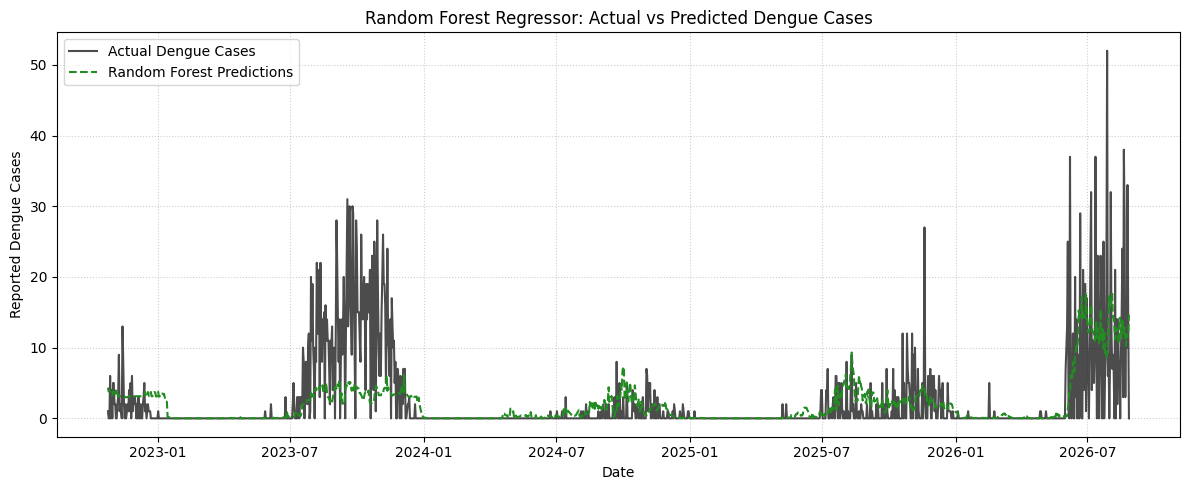

In [20]:
# 6. Plotting Actual vs Predicted Results
plt.figure(figsize=(12, 5))
plt.plot(all_dates, all_y_true, label="Actual Dengue Cases", color="black", alpha=0.7)
plt.plot(
    all_dates,
    all_y_pred,
    label="Random Forest Predictions",
    color="forestgreen",
    linestyle="--",
)
plt.title("Random Forest Regressor: Actual vs Predicted Dengue Cases")
plt.xlabel("Date")
plt.ylabel("Reported Dengue Cases")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig("random_forest_dengue_results.png", dpi=300)
print("\nSaved performance plot as 'random_forest_dengue_results.png'")
plt.show()